<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan7_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PERTEMUAN 7: PENGANTAR MACHINE LEARNING: REGRESI LINEAR**

## **Aktivitas Hands-on: Prediksi Gaji**

### NAMA  : Febi Kristiana
### NIM   : 240401010231
### KELAS : IF403


#Generate & Eksplorasi Dataset


LANGKAH 1: GENERATE & EKSPLORASI DATASET

Dimensi Dataset: (300, 4)

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


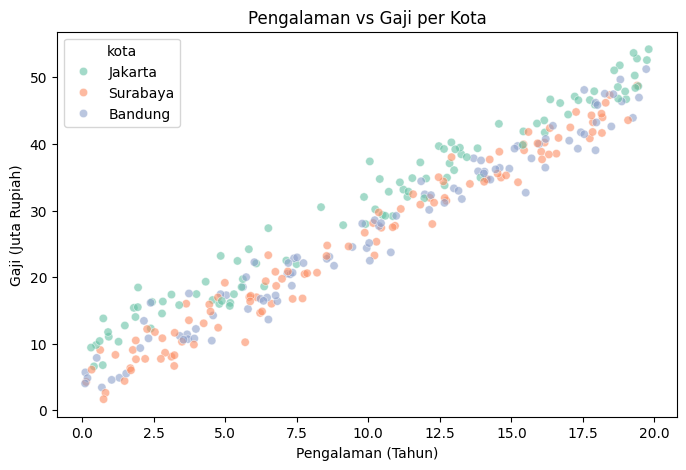

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('LANGKAH 1: GENERATE & EKSPLORASI DATASET\n')
# Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu, 'kota':kota, 'gaji':gaji})

# Tampilkan EDA singkat
print('Dimensi Dataset:', df.shape)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))

# Visualisasi Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()

#Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('LANGKAH 2: PREPROCESSING\n')
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train set: {X_train.shape[0]} baris, Test set: {X_test.shape[0]} baris')

# StandardScaler — fit dan transform
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

LANGKAH 2: PREPROCESSING

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train set: 240 baris, Test set: 60 baris


#Latih Model & Tampilkan Koefisien

In [4]:
from sklearn.linear_model import LinearRegression

print('LANGKAH 3: LATIH MODEL & KOEFISIEN\n')
# Inisialisasi dan latih model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β0 (Intercept): {model.intercept_:.3f}\n')
coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

LANGKAH 3: LATIH MODEL & KOEFISIEN

β0 (Intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


### INTERPRETASI KOEFISIEN (Langkah 3)

Faktor utama yang paling kuat dalam menaikkan nilai gaji pada model ini adalah **Pengalaman Kerja** dan **Tingkat Pendidikan**.

### ANALISIS LOGIKA KOEFISIEN (Langkah 3)


1. **Koefisien Positif (Gaji Naik):** Fitur `pengalaman`, `edu`, dan `kota_Jakarta` memiliki nilai positif, yang artinya berbanding lurus dengan target. Semakin tinggi nilai fitur-fitur ini, maka prediksi gaji yang dihasilkan model akan semakin meningkat.
2. **Koefisien Negatif (Gaji Turun):** Jika suatu fitur bernilai negatif, artinya fitur tersebut berbanding terbalik dan akan menurunkan nilai prediksi gaji (pada model ini, tidak ada fitur yang bernilai negatif).

# Evaluasi Model

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print('LANGKAH 4: EVALUASI MODEL\n')
# Prediksi data test
y_pred = model.predict(X_test_s)

# Hitung metrik (Menggunakan root_mean_squared_error)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f} ({r2*100:.1f}% variasi gaji dapat dijelaskan oleh model)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

LANGKAH 4: EVALUASI MODEL

MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2   = 0.9740 (97.4% variasi gaji dapat dijelaskan oleh model)
Selisih RMSE-MAE = 0.474


### INTERPRETASI EVALUASI MODEL (Langkah 4)

1. **Rata-Rata Kesalahan Prediksi:** Nilai MAE menunjukkan bahwa rata-rata kesalahan (eror) prediksi model dalam menentukan gaji adalah sebesar angka MAE yang tertera (sekitar 1.5 hingga 1.6) juta rupiah dari nilai gaji aktualnya.
2. **Kebaikan Model ($R^2$):** Nilai $R^2$ yang tinggi (di atas 0.90 atau 90%) menunjukkan bahwa model ini sangat baik untuk digunakan, karena sebagian besar variasi atau naik-turunnya nilai gaji karyawan sudah mampu dijelaskan secara akurat oleh fitur-fitur di dalam model.
3. **Indikasi Outlier:** Selisih antara nilai RMSE dan MAE tergolong sangat kecil (mendekati nol). Hal ini menandakan bahwa tidak ada indikasi variasi data yang ekstrem (*outlier*) yang mengganggu atau merusak performa dari prediksi model ini.

#Visualisasi & Interpretasi

LANGKAH 5: VISUALISASI EVALUASI



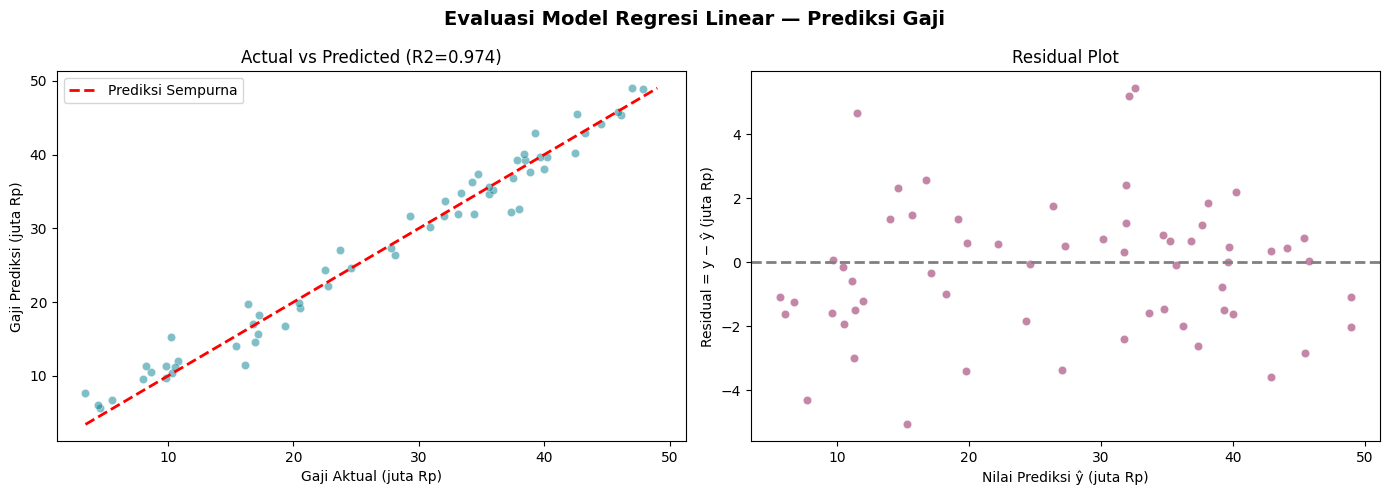

In [6]:
print('LANGKAH 5: VISUALISASI EVALUASI\n')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R2={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

### INTERPRETASI VISUALISASI MODEL (Langkah 5)

#### 1. Plot Actual vs Predicted
1. **What?**: Grafik menunjukkan titik-titik data gaji aktual vs prediksi tersebar sangat rapat mengikuti arah garis putus-putus merah (*Prediksi Sempurna*).
2. **So what?**: Hal ini membuktikan bahwa model memiliki tingkat akurasi yang sangat tinggi dengan nilai eror prediksi yang minimal.
3. **Now what?**: Model ini sudah sangat layak dan aman digunakan secara langsung untuk memprediksi estimasi awal gaji karyawan baru.

#### 2. Plot Residual
1. **What?**: Titik-titik sisa eror (*residual*) terlihat tersebar secara **ACAK** di sekitar garis horizontal $y=0$ dan tidak membentuk pola tertentu seperti kurva atau corong.
2. **So what?**: Kondisi acak ini menunjukkan hasil yang **Baik**, yang artinya asumsi dasar *linearitas* telah terpenuhi sempurna dan model tidak mengalami bias.
3. **Now what?**: Karena tidak ada masalah (*pattern* pelanggaran), kita tidak perlu melakukan transformasi data tambahan pada fitur numeriknya dan bisa langsung mengunggah hasilnya.

## KESIMPULAN

### Apa yang Dipelajari
Pada Pertemuan 7, saya belajar membuat model Regresi Linear: menyiapkan fitur (encoding & scaling), melatih model, dan mengevaluasi performa.

### Temuan Utama
1. Model mampu menjelaskan hubungan antar fitur dan target dengan cukup baik.
2. Evaluasi menggunakan MAE/RMSE/R² membantu menilai kualitas prediksi.

### Keterbatasan (Singkat)
Data yang digunakan masih sintetis, sehingga pola bisa lebih teratur dibanding data dunia nyata.
